# 02 — Data clean: predictor layers on their native grids (Colombia window)

Turns the raw downloads of `01b` into analysis-ready predictor layers for the
independent random-forest pipeline. Coarse layers stay on their native
lon/lat grids (written as NetCDF); `02b_feature_extraction` samples them at
30 m pixel centres (nearest neighbour). The 30 m Hansen layers are only
mosaicked (GDAL VRT), because the focal statistics are computed per tile in `02b`.

| Output (`data/clean/`) | What | Choice (see `docs/deviations.md`) |
|---|---|---|
| `bioclim_pca.nc`, `bioclim_pca_summary.csv` | PC1–PC5 of the 19 WorldClim bioclim variables | PCA re-derived on 1 M random global land points; centring and scaling chosen by matching Supp. Table 1 |
| `soil_0_30cm.nc` | OCDENS, PHIHOX, top 30 cm | trapezoidal depth weighting of 0, 5, 15, 30 cm |
| `landcover.nc` | ESA CCI LC 1992 / 1999 / 2000 / 2015 in 11 classes, cropland density (5 km), distance to urban | 31 → 11 class mapping defined here |
| `npp.nc`, `roads.nc`, `burned.nc` | NPP mean 2000–2015; GRIP4 road density; fraction of months burned 2001–2017 | — |
| `biomes_colombia.parquet` | RESOLVE 2017 biomes clipped to the window | study biomes 1, 2, 3 |
| `hansen_<layer>.vrt`, `srtm.vrt` | mosaics | — |

**Smoke mode** (`SMOKE=1`): outputs go to `data/clean_smoke/`; the PCA sample is
20,000 points drawn inside the smoke sub-window only (tests the code path, not
the science).

In [1]:
import json
import os
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shapely
import xarray as xr
from osgeo import gdal
from rasterio.features import rasterize
from rasterio.transform import from_origin
from rasterio.windows import from_bounds
from scipy import ndimage, signal

gdal.UseExceptions()

In [2]:
RAW = Path("../data/raw")
SMOKE = os.environ.get("SMOKE", "0") == "1"
SMOKE_BBOX = (-75.0, 4.0, -73.0, 6.0)
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
CLEAN.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SEED = 20261003

col = gpd.read_file(RAW / "gadm" / "gadm41_COL.gpkg", layer="ADM_ADM_0")
COL_GEOM = shapely.make_valid(col.geometry.iloc[0])
W, S, E, N = COL_GEOM.bounds
BBOX = (np.floor(W - 0.5), np.floor(S - 0.5), np.ceil(E + 0.5), np.ceil(N + 0.5))
print("window", BBOX)

WGS84_A, WGS84_F = 6378137.0, 1 / 298.257223563
E2 = WGS84_F * (2 - WGS84_F)


def metres_per_degree(lat: float) -> tuple[float, float]:
    """(north-south, east-west) metres per degree on the WGS84 ellipsoid at latitude lat."""
    phi = np.radians(lat)
    s2 = np.sin(phi) ** 2
    m = WGS84_A * (1 - E2) / (1 - E2 * s2) ** 1.5
    n = WGS84_A / np.sqrt(1 - E2 * s2)
    return float(np.radians(1) * m), float(np.radians(1) * n * np.cos(phi))


def grid_coords(transform, shape) -> tuple[np.ndarray, np.ndarray]:
    lon = transform.c + (np.arange(shape[1]) + 0.5) * transform.a
    lat = transform.f + (np.arange(shape[0]) + 0.5) * transform.e
    return lat, lon


def to_dataarray(arr: np.ndarray, transform, name: str, attrs: dict) -> xr.DataArray:
    lat, lon = grid_coords(transform, arr.shape)
    return xr.DataArray(arr, dims=("lat", "lon"), coords={"lat": lat, "lon": lon}, name=name, attrs=attrs)


def read_window(path: str, bbox=BBOX) -> tuple[np.ndarray, object, float | None]:
    with rasterio.open(path) as src:
        win = from_bounds(*bbox, transform=src.transform).round_offsets().round_lengths()
        return src.read(1, window=win, boundless=True, fill_value=src.nodata or 0), src.window_transform(win), src.nodata

window (np.float64(-83.0), np.float64(-5.0), np.float64(-66.0), np.float64(17.0))


## 1. Bioclim PCA (WorldClim v2.1, 30 s)

Paper (Methods): 1 million random points within land areas, the 19 values per
point, R `prcomp`, then `predict.prcomp` on all pixels; first five components.
Centring / scaling is not reported, and Supp. Table 1 reports only component
standard deviations. We sample 1,000,000 points uniformly by area on the sphere
(latitude = arcsin(U(-1, 1))), keep those on a valid WorldClim pixel, and fit
both `prcomp` variants (centre only = R default; centre + scale). The variant
whose component SDs match Supp. Table 1 is used.

In [3]:
WC_ZIP = (RAW / "worldclim" / "wc2.1_30s_bio.zip").resolve()
WC = [f"/vsizip/{WC_ZIP}/wc2.1_30s_bio_{i}.tif" for i in range(1, 20)]
SUPP_T1_SD = np.array([780.4, 362.0, 146.8, 103.1, 59.7])
pca_sample_path = CLEAN / "bioclim_pca_sample.parquet"

if SMOKE and not pca_sample_path.exists():
    rng = np.random.default_rng(SEED)
    lon = rng.uniform(SMOKE_BBOX[0], SMOKE_BBOX[2], 40_000)
    s0, s1 = np.sin(np.radians(SMOKE_BBOX[1])), np.sin(np.radians(SMOKE_BBOX[3]))
    lat = np.degrees(np.arcsin(rng.uniform(s0, s1, 40_000)))
    vals = {}
    for i, path in enumerate(WC, start=1):
        with rasterio.open(path) as src:
            win = from_bounds(*SMOKE_BBOX, transform=src.transform).round_offsets().round_lengths()
            a = src.read(1, window=win)
            wt = src.window_transform(win)
            r = np.clip(((wt.f - lat) / -wt.e).astype(int), 0, a.shape[0] - 1)
            c = np.clip(((lon - wt.c) / wt.a).astype(int), 0, a.shape[1] - 1)
            v = a[r, c].astype("float64")
            v[a[r, c] == src.nodata] = np.nan
            vals[f"bio{i}"] = v
            tr = src.transform
    sample = pd.DataFrame(vals)
    sample["row"] = ((tr.f - lat) / -tr.e).astype(int)
    sample["col"] = ((lon - tr.c) / tr.a).astype(int)
    sample = sample.dropna().iloc[:20_000]
    sample.to_parquet(pca_sample_path)
if not pca_sample_path.exists():
    rng = np.random.default_rng(SEED)
    with rasterio.open(WC[0]) as src:
        bio1 = src.read(1)
        tr, nod = src.transform, src.nodata
    rows_all, cols_all = [], []
    while sum(len(r) for r in rows_all) < 1_000_000:
        n = 3_000_000
        lon = rng.uniform(-180, 180, n)
        lat = np.degrees(np.arcsin(rng.uniform(-1, 1, n)))
        r = np.clip(((tr.f - lat) / -tr.e).astype(int), 0, bio1.shape[0] - 1)
        c = np.clip(((lon - tr.c) / tr.a).astype(int), 0, bio1.shape[1] - 1)
        ok = bio1[r, c] != nod
        rows_all.append(r[ok])
        cols_all.append(c[ok])
    rows = np.concatenate(rows_all)[:1_000_000]
    cols = np.concatenate(cols_all)[:1_000_000]
    del bio1
    vals = {}
    for i, path in enumerate(WC, start=1):
        with rasterio.open(path) as src:
            vals[f"bio{i}"] = src.read(1)[rows, cols].astype("float64")
        print("sampled", Path(path).name, flush=True)
    sample = pd.DataFrame(vals)
    sample["row"], sample["col"] = rows, cols
    sample.to_parquet(pca_sample_path)
sample = pd.read_parquet(pca_sample_path)
bio_cols = [f"bio{i}" for i in range(1, 20)]
X = sample[bio_cols].to_numpy()
print(len(X), "points; any NaN:", np.isnan(X).any())

1000000 points; any NaN: False


In [4]:
pca_variants = {}
for name, scale in [("centre_only", False), ("centre_scale", True)]:
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=1) if scale else np.ones(X.shape[1])
    Z = (X - mu) / sd
    cov = np.cov(Z, rowvar=False)
    eigval, eigvec = np.linalg.eigh(cov)
    order = np.argsort(eigval)[::-1]
    eigval, eigvec = eigval[order], eigvec[:, order]
    pca_variants[name] = dict(center=mu, scale=sd, sdev=np.sqrt(eigval), rotation=eigvec,
                              prop=eigval / eigval.sum())
summary = pd.DataFrame({
    "component": [f"PC{i}" for i in range(1, 6)],
    "supp_table1_sd": SUPP_T1_SD,
    **{f"{k}_sd": v["sdev"][:5] for k, v in pca_variants.items()},
    **{f"{k}_cumprop": np.cumsum(v["prop"])[:5] for k, v in pca_variants.items()},
})
summary.to_csv(CLEAN / "bioclim_pca_summary.csv", index=False)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
err = {k: float(np.abs(np.log(v["sdev"][:5] / SUPP_T1_SD)).mean()) for k, v in pca_variants.items()}
PCA_CHOICE = min(err, key=err.get)
print("mean |log SD ratio| vs Supp. Table 1:", err, "-> using", PCA_CHOICE)
pca = pca_variants[PCA_CHOICE]
pd.DataFrame(pca["rotation"][:, :5], index=bio_cols, columns=[f"PC{i}" for i in range(1, 6)]).assign(
    center=pca["center"], scale=pca["scale"]).to_csv(CLEAN / "bioclim_pca_loadings.csv")

component  supp_table1_sd  centre_only_sd  centre_scale_sd  centre_only_cumprop  centre_scale_cumprop
      PC1           780.4           893.2            3.103               0.7913                0.5069
      PC2             362             387            2.069               0.9399                0.7323
      PC3           146.8           184.4            1.393               0.9736                0.8344
      PC4           103.1             131             1.11               0.9906                0.8993
      PC5            59.7           76.16           0.8074               0.9964                0.9336
mean |log SD ratio| vs Supp. Table 1: {'centre_only': 0.18261746757673472, 'centre_scale': 4.836777161959005} -> using centre_only


In [5]:
pcs_out = CLEAN / "bioclim_pca.nc"
if not pcs_out.exists():
    stack = []
    for path in WC:
        arr, tr, nod = read_window(path)
        stack.append(np.where(arr == nod, np.nan, arr).astype("float64"))
    stack = np.stack(stack, axis=-1)
    Z = (stack - pca["center"]) / pca["scale"]
    pcs = Z @ pca["rotation"][:, :5]
    ds = xr.Dataset({f"pc{i + 1}": to_dataarray(pcs[..., i].astype("float32"), tr, f"pc{i + 1}", {})
                     for i in range(5)})
    ds.attrs = {"pca_variant": PCA_CHOICE, "source": "WorldClim v2.1 30 s bioclim; PCA on 1e6 global land points"}
    ds.to_netcdf(pcs_out)
print(xr.open_dataset(pcs_out))

<xarray.Dataset> Size: 108MB
Dimensions:  (lat: 2640, lon: 2040)
Coordinates:
  * lat      (lat) float64 21kB 17.0 16.99 16.98 16.97 ... -4.979 -4.988 -4.996
  * lon      (lon) float64 16kB -83.0 -82.99 -82.98 ... -66.02 -66.01 -66.0
Data variables:
    pc1      (lat, lon) float32 22MB ...
    pc2      (lat, lon) float32 22MB ...
    pc3      (lat, lon) float32 22MB ...
    pc4      (lat, lon) float32 22MB ...
    pc5      (lat, lon) float32 22MB ...
Attributes:
    pca_variant:  centre_only
    source:       WorldClim v2.1 30 s bioclim; PCA on 1e6 global land points


## 1b. Sensitivity check (not a fix): CHELSA v2.1 bioclim, 1981–2010

Same procedure, same 1,000,000 sample points (WorldClim pixel centres, mapped to
the nearest CHELSA pixel), same PCA variant. CHELSA's period (1981–2010) overlaps
the 2000–2012 outcome period, so this is a **sensitivity check of the climate
source**, not a temporally cleaner predictor. Files are read remotely
(`/vsicurl/`, strip by strip, nothing stored): the CHELSA GeoTIFFs are
strip-organised, not COGs, so every row is read once (~5.8 GB transfer).
Values are converted with the files' scale/offset; 65535 is treated as NoData.
Points north of 84°N (outside CHELSA) or NoData are dropped from both fits.

In [6]:
CHELSA = ("https://os.zhdk.cloud.switch.ch/chelsav2/GLOBAL/climatologies/1981-2010/bio/"
          "CHELSA_bio{i}_1981-2010_V.2.1.tif")
chelsa_sample_path = CLEAN / "chelsa_pca_sample.parquet"
chelsa_win_path = CLEAN / "chelsa_window.nc"
gdal.SetConfigOption("GDAL_HTTP_MAX_RETRY", "10")
gdal.SetConfigOption("GDAL_HTTP_RETRY_DELAY", "5")
gdal.SetConfigOption("CPL_VSIL_CURL_CHUNK_SIZE", "8388608")
gdal.SetConfigOption("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")

with rasterio.open(WC[0]) as src:
    wc_tr = src.transform
pt_lon = wc_tr.c + (sample["col"].to_numpy() + 0.5) * wc_tr.a
pt_lat = wc_tr.f + (sample["row"].to_numpy() + 0.5) * wc_tr.e

if not (chelsa_sample_path.exists() and chelsa_win_path.exists()):
    cvals, cwin = {}, {}
    for i in range(1, 20):
        with rasterio.open("/vsicurl/" + CHELSA.format(i=i)) as src:
            tr, sc, off = src.transform, src.scales[0], src.offsets[0]
            r = np.floor((tr.f - pt_lat) / -tr.e).astype(int)
            c = np.clip(np.floor((pt_lon - tr.c) / tr.a).astype(int), 0, src.width - 1)
            inside = (r >= 0) & (r < src.height)
            vals = np.full(len(pt_lon), np.nan)
            wwin = from_bounds(*BBOX, transform=tr).round_offsets().round_lengths()
            wr0, wr1 = int(wwin.row_off), int(wwin.row_off + wwin.height)
            win_rows = []
            step = 512
            for r0 in range(0, src.height, step):
                n = min(step, src.height - r0)
                need = inside & (r >= r0) & (r < r0 + n)
                touches_win = r0 < wr1 and r0 + n > wr0
                if not need.any() and not touches_win:
                    continue
                block = src.read(1, window=rasterio.windows.Window(0, r0, src.width, n))
                vals[need] = block[r[need] - r0, c[need]]
                if touches_win:
                    a, b = max(r0, wr0), min(r0 + n, wr1)
                    win_rows.append(block[a - r0:b - r0, int(wwin.col_off):int(wwin.col_off + wwin.width)])
            vals[vals == 65535] = np.nan
            cvals[f"bio{i}"] = vals * sc + off
            w = np.concatenate(win_rows).astype("float64")
            w[w == 65535] = np.nan
            cwin[f"bio{i}"] = (w * sc + off, src.window_transform(wwin))
        print("CHELSA bio", i, "done", flush=True)
    pd.DataFrame(cvals).to_parquet(chelsa_sample_path)
    wtr = cwin["bio1"][1]
    xr.Dataset({k: to_dataarray(v[0].astype("float32"), wtr, k, {}) for k, v in cwin.items()}).to_netcdf(chelsa_win_path)

csample = pd.read_parquet(chelsa_sample_path)
both_ok = ~csample[bio_cols].isna().any(axis=1).to_numpy()
print(f"CHELSA: {both_ok.sum():,} of {len(csample):,} sample points valid")
Xc = csample.loc[both_ok, bio_cols].to_numpy()
mu_c = Xc.mean(axis=0)
sd_c = Xc.std(axis=0, ddof=1) if PCA_CHOICE == "centre_scale" else np.ones(Xc.shape[1])
ev_c, evec_c = np.linalg.eigh(np.cov((Xc - mu_c) / sd_c, rowvar=False))
o = np.argsort(ev_c)[::-1]
ev_c, evec_c = ev_c[o], evec_c[:, o]
summary["chelsa_sd"] = np.sqrt(ev_c[:5])
summary["chelsa_cumprop"] = np.cumsum(ev_c / ev_c.sum())[:5]
summary.to_csv(CLEAN / "bioclim_pca_summary.csv", index=False)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

cpcs_out = CLEAN / "chelsa_pca.nc"
if not cpcs_out.exists():
    cw = xr.open_dataset(chelsa_win_path)
    st = np.stack([cw[b].values.astype("float64") for b in bio_cols], axis=-1)
    cp = ((st - mu_c) / sd_c) @ evec_c[:, :5]
    lat, lon = cw.lat.values, cw.lon.values
    xr.Dataset({f"cpc{i + 1}": xr.DataArray(cp[..., i].astype("float32"), dims=("lat", "lon"),
                                            coords={"lat": lat, "lon": lon}) for i in range(5)},
               attrs={"pca_variant": PCA_CHOICE, "source": "CHELSA v2.1 1981-2010 bioclim; sensitivity check",
                      "url_template": CHELSA}).to_netcdf(cpcs_out)
print(xr.open_dataset(cpcs_out))

CHELSA: 998,736 of 1,000,000 sample points valid


component  supp_table1_sd  centre_only_sd  centre_scale_sd  centre_only_cumprop  centre_scale_cumprop  chelsa_sd  chelsa_cumprop
      PC1           780.4           893.2            3.103               0.7913                0.5069      989.3          0.8072
      PC2             362             387            2.069               0.9399                0.7323      391.5          0.9336
      PC3           146.8           184.4            1.393               0.9736                0.8344      217.1          0.9725
      PC4           103.1             131             1.11               0.9906                0.8993      148.9          0.9908
      PC5            59.7           76.16           0.8074               0.9964                0.9336      85.69          0.9968


<xarray.Dataset> Size: 108MB
Dimensions:  (lat: 2640, lon: 2040)
Coordinates:
  * lat      (lat) float64 21kB 17.0 16.99 16.98 16.97 ... -4.979 -4.988 -4.996
  * lon      (lon) float64 16kB -83.0 -82.99 -82.98 ... -66.02 -66.01 -66.0
Data variables:
    cpc1     (lat, lon) float32 22MB ...
    cpc2     (lat, lon) float32 22MB ...
    cpc3     (lat, lon) float32 22MB ...
    cpc4     (lat, lon) float32 22MB ...
    cpc5     (lat, lon) float32 22MB ...
Attributes:
    pca_variant:   centre_only
    source:        CHELSA v2.1 1981-2010 bioclim; sensitivity check
    url_template:  https://os.zhdk.cloud.switch.ch/chelsav2/GLOBAL/climatolog...


## 2. Soil: OCDENS and PHIHOX, top 30 cm (SoilGrids250m v2017)

Depth-weighted mean over 0–30 cm by the trapezoidal rule on the standard depths
0, 5, 15 and 30 cm (sl1–sl4): (5·(x1+x2)/2 + 10·(x2+x3)/2 + 15·(x3+x4)/2) / 30.
Units: OCDENS kg m⁻³; PHIHOX pH × 10.

In [7]:
soil_out = CLEAN / "soil_0_30cm.nc"
if not soil_out.exists():
    layers = {}
    for var in ["OCDENS", "PHIHOX"]:
        xs = []
        for d in [1, 2, 3, 4]:
            with rasterio.open(RAW / "soilgrids2017" / f"{var}_M_sl{d}_colombia.tif") as src:
                a = src.read(1).astype("float32")
                nod = src.nodata
                tr = src.transform
            if nod is not None:
                a[a == nod] = np.nan
            xs.append(a)
        x1, x2, x3, x4 = xs
        layers[var.lower()] = to_dataarray(
            ((5 * (x1 + x2) / 2 + 10 * (x2 + x3) / 2 + 15 * (x3 + x4) / 2) / 30).astype("float32"), tr, var.lower(),
            {"units": "kg m-3" if var == "OCDENS" else "pH x 10", "depth": "0-30 cm trapezoidal"})
    xr.Dataset(layers).to_netcdf(soil_out)
print(xr.open_dataset(soil_out))

<xarray.Dataset> Size: 690MB
Dimensions:  (lat: 10560, lon: 8160)
Coordinates:
  * lat      (lat) float64 84kB 17.0 17.0 17.0 16.99 ... -4.994 -4.996 -4.998
  * lon      (lon) float64 65kB -83.0 -83.0 -82.99 -82.99 ... -66.01 -66.0 -66.0
Data variables:
    ocdens   (lat, lon) float32 345MB ...
    phihox   (lat, lon) float32 345MB ...


## 3. Land cover: ESA CCI 31 → 11 classes, cropland density, distance to urban

The paper simplified the ESA CCI legend to 11 classes without listing them
(gap). Our mapping:

In [8]:
LC11 = {
    1: ("cropland", [10, 11, 12, 20]),
    2: ("mosaic cropland / natural vegetation", [30, 40]),
    3: ("tree cover", [50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90]),
    4: ("mosaic tree-shrub / herbaceous", [100, 110]),
    5: ("shrubland", [120, 121, 122]),
    6: ("grassland, lichens and mosses", [130, 140]),
    7: ("sparse vegetation", [150, 151, 152, 153]),
    8: ("flooded vegetation", [160, 170, 180]),
    9: ("urban", [190]),
    10: ("bare areas, permanent snow and ice", [200, 201, 202, 220]),
    11: ("water", [210]),
}
lut = np.zeros(256, dtype="uint8")
for k, (_, codes) in LC11.items():
    lut[codes] = k
pd.DataFrame([(k, v[0], " ".join(map(str, v[1]))) for k, v in LC11.items()],
             columns=["class", "name", "esa_cci_codes"]).to_csv(CLEAN / "landcover_classes.csv", index=False)

CROPLAND_CODES = [10, 11, 12, 20, 30]
CROP_RADIUS_M, LAT_REF = 5000.0, 0.5 * (S + N)


def disk_kernel(radius_m: float, dy_m: float, dx_m: float) -> np.ndarray:
    ry, rx = int(np.ceil(radius_m / dy_m)), int(np.ceil(radius_m / dx_m))
    yy, xx = np.mgrid[-ry:ry + 1, -rx:rx + 1]
    k = ((yy * dy_m) ** 2 + (xx * dx_m) ** 2 <= radius_m**2).astype("float32")
    return k / k.sum()


lc_out = CLEAN / "landcover.nc"
if not lc_out.exists():
    out = {}
    for year in [1992, 1999, 2000, 2015]:
        with rasterio.open(RAW / "esacci_lc" / f"esacci_lc_{year}_colombia.tif") as src:
            raw = src.read(1)
            tr = src.transform
        mdeg_y, mdeg_x = metres_per_degree(LAT_REF)
        dy, dx = abs(tr.e) * mdeg_y, tr.a * mdeg_x
        out[f"lc_{year}"] = to_dataarray(lut[raw], tr, f"lc_{year}", {"classes": "see landcover_classes.csv"})
        out[f"esa_{year}"] = to_dataarray(raw, tr, f"esa_{year}", {"legend": "ESA CCI LCCS"})
        if year in (2000, 2015):
            crop = np.isin(raw, CROPLAND_CODES).astype("float32")
            dens = signal.oaconvolve(crop, disk_kernel(CROP_RADIUS_M, dy, dx), mode="same")
            out[f"cropland_density_{year}"] = to_dataarray(np.clip(dens, 0, 1).astype("float32"), tr,
                                                           f"cropland_density_{year}", {"units": "fraction, 5 km radius"})
            urban = raw == 190
            dist = ndimage.distance_transform_edt(~urban, sampling=(dy, dx)).astype("float32")
            out[f"dist_urban_{year}"] = to_dataarray(dist, tr, f"dist_urban_{year}", {"units": "m"})
    xr.Dataset(out).to_netcdf(lc_out)
print(xr.open_dataset(lc_out))

<xarray.Dataset> Size: 1GB
Dimensions:                (lat: 7920, lon: 6120)
Coordinates:
  * lat                    (lat) float64 63kB 17.0 17.0 16.99 ... -4.996 -4.999
  * lon                    (lon) float64 49kB -83.0 -83.0 -82.99 ... -66.0 -66.0
Data variables:
    lc_1992                (lat, lon) uint8 48MB ...
    esa_1992               (lat, lon) uint8 48MB ...
    lc_1999                (lat, lon) uint8 48MB ...
    esa_1999               (lat, lon) uint8 48MB ...
    lc_2000                (lat, lon) uint8 48MB ...
    esa_2000               (lat, lon) uint8 48MB ...
    cropland_density_2000  (lat, lon) float32 194MB ...
    dist_urban_2000        (lat, lon) float32 194MB ...
    lc_2015                (lat, lon) uint8 48MB ...
    esa_2015               (lat, lon) uint8 48MB ...
    cropland_density_2015  (lat, lon) float32 194MB ...
    dist_urban_2015        (lat, lon) float32 194MB ...


## 4. NPP, road density, burned area

In [9]:
npp_out = CLEAN / "npp.nc"
if not npp_out.exists():
    with rasterio.open(RAW / "npp" / "MOD17A3_NPP_mean_00_15_colombia.tif") as src:
        a = src.read(1).astype("float32")
        tr, nod = src.transform, src.nodata
    print("NPP raw range:", np.nanmin(a), np.nanmax(a), "nodata", nod)
    valid = (a >= 0) & (a <= 65500) & (a != (nod if nod is not None else -1))
    npp = np.where(valid, a * 0.0001, np.nan).astype("float32")  # kg C m-2 yr-1 (NTSG scale factor)
    xr.Dataset({"npp": to_dataarray(npp, tr, "npp", {"units": "kg C m-2 yr-1", "period": "mean 2000-2015"})}).to_netcdf(npp_out)
print(xr.open_dataset(npp_out))

NPP raw range: 0.0 65535.0 nodata None
<xarray.Dataset> Size: 22MB
Dimensions:  (lat: 2640, lon: 2040)
Coordinates:
  * lat      (lat) float64 21kB 17.0 16.99 16.98 16.97 ... -4.979 -4.988 -4.996
  * lon      (lon) float64 16kB -83.0 -82.99 -82.98 ... -66.02 -66.01 -66.0
Data variables:
    npp      (lat, lon) float32 22MB ...


In [10]:
roads_out = CLEAN / "roads.nc"
if not roads_out.exists():
    zpath = (RAW / "grip4" / "GRIP4_density_total.zip").resolve()
    tif = "grip4_total_dens_m_km2.asc"  # the zip also holds grip4_area_land_km2.asc (land area, not roads)
    assert tif in zipfile.ZipFile(zpath).namelist()
    a, tr, nod = read_window(f"/vsizip/{zpath}/{tif}")
    a = np.where(a == nod, np.nan, a).astype("float32") if nod is not None else a.astype("float32")
    xr.Dataset({"road_density": to_dataarray(a, tr, "road_density", {"units": "m km-2", "source": tif})}).to_netcdf(roads_out)
print(xr.open_dataset(roads_out))

<xarray.Dataset> Size: 219kB
Dimensions:       (lat: 264, lon: 204)
Coordinates:
  * lat           (lat) float64 2kB 16.96 16.88 16.79 ... -4.792 -4.875 -4.958
  * lon           (lon) float64 2kB -82.96 -82.88 -82.79 ... -66.12 -66.04
Data variables:
    road_density  (lat, lon) float32 215kB ...


Burned area: GlobFire monthly `FinalArea` polygons (final perimeter of each fire
event; 2001-01 … 2017-12, 204 months) are rasterised (pixel-centre rule) onto a 15 arc-second (~460 m, MODIS-like) grid;
the variable is the fraction of the 204 months in which the pixel burned
("monthly average of burned area", paper Methods).

In [11]:
burn_out = CLEAN / "burned.nc"
burned_source = json.load(open(RAW / ("burned_source_smoke.json" if SMOKE else "burned_source.json")))
print("burned-area source:", burned_source)
if not burn_out.exists() and burned_source["source"] != "globfire":
    if burned_source["source"] == "mcd64a1":
        with rasterio.open(RAW / "mcd64a1" / burned_source["mcd64a1_file"]) as src:
            cnt = src.read(1).astype("float32")
            tr = src.transform
        frac = cnt / burned_source["months"]
    else:
        res = 1 / 240
        tr = from_origin(BBOX[0], BBOX[3], res, res)
        frac = np.full((int(round((BBOX[3] - BBOX[1]) / res)), int(round((BBOX[2] - BBOX[0]) / res))), np.nan, "float32")
    xr.Dataset({"burned_frac": to_dataarray(frac.astype("float32"), tr, "burned_frac",
                                            {"units": "fraction of months burned", "source": burned_source["source"],
                                             "months": burned_source["months"]})}).to_netcdf(burn_out)
if not burn_out.exists():
    res = 1 / 240
    tr = from_origin(BBOX[0], BBOX[3], res, res)
    shape = (int(round((BBOX[3] - BBOX[1]) / res)), int(round((BBOX[2] - BBOX[0]) / res)))
    count = np.zeros(shape, dtype="uint16")
    BURN_TYPE = "FinalArea"  # final perimeter of each fire event (ActiveArea = daily spread)
    files = sorted((RAW / "globfire").glob("globfire_*_colombia.parquet"))
    if SMOKE:
        files = [f for f in files if f.name in ("globfire_2005_01_colombia.parquet", "globfire_2005_02_colombia.parquet")]
    else:
        files = [f for f in files if 2001 <= int(f.name.split("_")[1]) <= 2017]
    assert len(files) == burned_source["months"], (len(files), burned_source)
    types = {}
    for f in files:
        g = gpd.read_parquet(f)
        for t, n in g["Type"].value_counts().items():
            types[t] = types.get(t, 0) + n
        g = g[g["Type"] == BURN_TYPE]
        if len(g):
            count += rasterize(((geom, 1) for geom in g.geometry), out_shape=shape, transform=tr,
                               fill=0, dtype="uint8")
    print("GlobFire polygon types over all months:", types)
    frac = (count / len(files)).astype("float32")
    xr.Dataset({"burned_frac": to_dataarray(frac, tr, "burned_frac",
                                            {"units": "fraction of months burned", "months": len(files),
                                             "polygon_type": BURN_TYPE})}).to_netcdf(burn_out)
print(xr.open_dataset(burn_out))

burned-area source: {'source': 'globfire', 'months': 204, 'globfire_failed': [], 'mcd64a1_file': None}


GlobFire polygon types over all months: {'ActiveArea': 1531488, 'FinalArea': 259995}


<xarray.Dataset> Size: 86MB
Dimensions:      (lat: 5280, lon: 4080)
Coordinates:
  * lat          (lat) float64 42kB 17.0 16.99 16.99 ... -4.99 -4.994 -4.998
  * lon          (lon) float64 33kB -83.0 -82.99 -82.99 ... -66.01 -66.01 -66.0
Data variables:
    burned_frac  (lat, lon) float32 86MB ...


## 5. Biomes (RESOLVE Ecoregions 2017)

In [12]:
biome_out = CLEAN / "biomes_colombia.parquet"
if not biome_out.exists():
    eco = gpd.read_file(f"/vsizip/{(RAW / 'ecoregions' / 'Ecoregions2017.zip').resolve()}", bbox=BBOX)
    eco = eco[["BIOME_NUM", "BIOME_NAME", "ECO_NAME", "geometry"]].copy()
    eco["geometry"] = shapely.make_valid(eco.geometry.values)
    biomes = eco.dissolve(by=["BIOME_NUM", "BIOME_NAME"], as_index=False)[["BIOME_NUM", "BIOME_NAME", "geometry"]]
    biomes["geometry"] = biomes.geometry.clip_by_rect(*BBOX)
    biomes.to_parquet(biome_out)
biomes = gpd.read_parquet(biome_out)
geod_areas = biomes.to_crs("EPSG:4326").geometry.intersection(COL_GEOM)
from pyproj import Geod  # noqa: E402

g = Geod(ellps="WGS84")
biomes["area_in_colombia_mha"] = [abs(g.geometry_area_perimeter(x)[0]) / 1e10 for x in geod_areas]
print(biomes.drop(columns="geometry").to_string(index=False))

 BIOME_NUM                                               BIOME_NAME  area_in_colombia_mha
       1.0           Tropical & Subtropical Moist Broadleaf Forests             85.389188
       2.0             Tropical & Subtropical Dry Broadleaf Forests              7.851746
       7.0 Tropical & Subtropical Grasslands, Savannas & Shrublands             15.261266
       9.0                            Flooded Grasslands & Savannas              0.000000
      10.0                          Montane Grasslands & Shrublands              1.547240
      13.0                               Deserts & Xeric Shrublands              2.745171
      14.0                                                Mangroves              0.823897


## 6. Mosaics: Hansen GFC layers and SRTM (VRT)

In [13]:
for layer in ["treecover2000", "gain", "lossyear"]:
    files = sorted(str(p.resolve()) for p in (RAW / "hansen").glob(f"*_{layer}_*.tif"))
    gdal.BuildVRT(str(CLEAN / f"hansen_{layer}.vrt"), files).FlushCache()
srtm = sorted(f"/vsizip/{p.resolve()}/{p.name.replace('.SRTMGL1.hgt.zip', '.hgt')}"
              for p in (RAW / "srtm").glob("*.hgt.zip"))
gdal.BuildVRT(str(CLEAN / "srtm.vrt"), srtm).FlushCache()
for v in ["hansen_treecover2000.vrt", "srtm.vrt"]:
    with rasterio.open(CLEAN / v) as src:
        print(v, src.bounds, src.res, src.dtypes)

hansen_treecover2000.vrt BoundingBox(left=-90.0, bottom=-10.0, right=-60.0, top=20.0) (0.00025, 0.00025) ('uint8',)
srtm.vrt BoundingBox(left=-82.00013888888888, bottom=-5.000138888888891, right=-65.9998611111111, top=16.000138888888888) (0.0002777777777777778, 0.0002777777777777778) ('int16',)


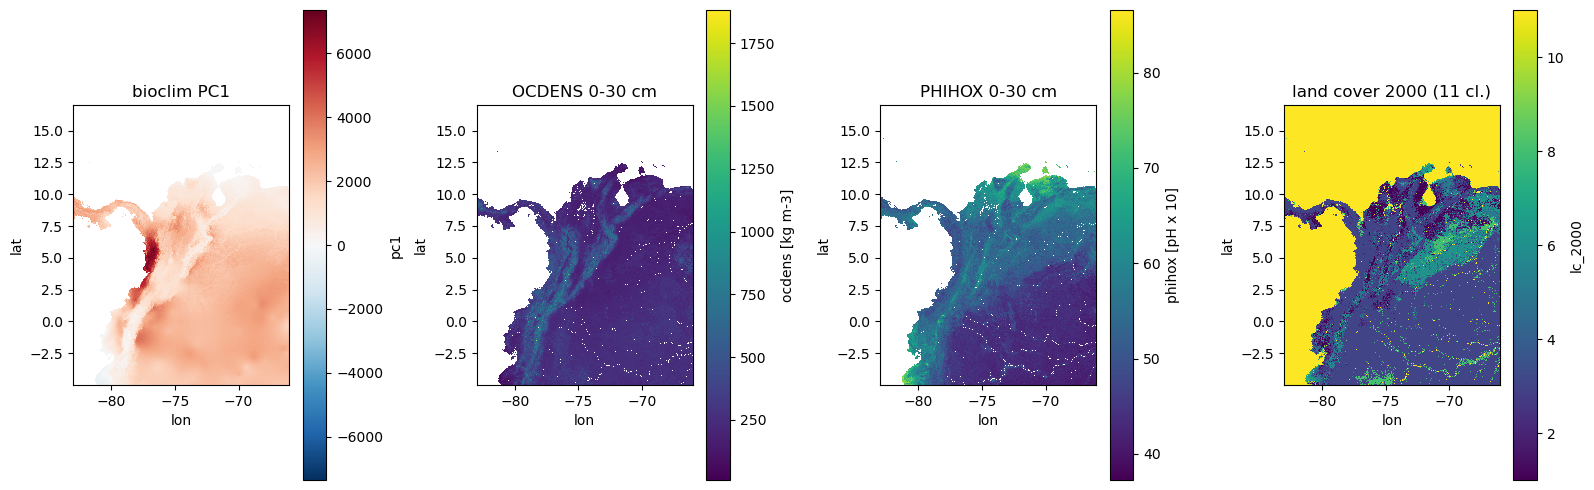

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
pcs = xr.open_dataset(pcs_out)
soil = xr.open_dataset(soil_out)
lc = xr.open_dataset(lc_out)
for ax, (da, title) in zip(axes, [(pcs.pc1, "bioclim PC1"), (soil.ocdens, "OCDENS 0-30 cm"),
                                  (soil.phihox, "PHIHOX 0-30 cm"), (lc.lc_2000, "land cover 2000 (11 cl.)")]):
    da[::4, ::4].plot(ax=ax, add_colorbar=True)
    ax.set_title(title)
    ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIGURES / "predictors_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
json.dump({"pca_variant": PCA_CHOICE, "pca_sd_error": err}, open(CLEAN / "clean_meta.json", "w"), indent=2)